In [1]:
import os
import yaml
import dotenv
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAI, GoogleGenerativeAIEmbeddings

In [2]:
env_path = r"D:\common_credentials\.env"
load_dotenv(dotenv_path=env_path)

True

In [3]:
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display
from typing import Dict, TypedDict, List, Any, Annotated #Annotated is used to add extra metadata to the str type, like a comment or description.
from langgraph.graph.message import add_messages

In [4]:
llm= ChatGroq(model="qwen-2.5-32b")

In [32]:
import os
import uuid
import json
from typing import Optional
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolExecutor
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolExecutor
from langchain_core.messages import ToolMessage
from langgraph.prebuilt import ToolInvocation
from langgraph.graph import END, StateGraph
from langchain_core.messages import AIMessage
from langchain_core.messages import HumanMessage
# from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.tools import tool
from langchain_core.messages import AIMessage
import streamlit as st
from langchain_community.tools.tavily_search import TavilySearchResults

In [30]:
!pip install langgraph-checkpoint-sqlite -q

In [12]:
model= ChatGroq(model="qwen-2.5-32b")

In [13]:
# State
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [40]:
from langgraph.prebuilt import ToolNode
## define the tools 
@tool
def add(a:int,b:int)->int:
    """adding tqo numbers"""
    return a + b

@tool
def multiply(a:int,b:int)->int:
    """multiply tqo numbers"""
    return a * b

tavilytool= TavilySearchResults(max_results=2)

# tools list
tools_list= [add, multiply, tavilytool]

# tool_executor= ToolExecutor(tools_list) #Deprecated
tool_executor=ToolNode(tools_list)

#model
model= model.bind_tools(tools_list)


In [41]:
#Define the function that determines the whether to continue the flow or noct

def should_continue(state:State):
    messages= state['messages']
    last_message= messages[-1]
    if not last_message.tool_calls:
        return 'end'
    else:
        return 'continue'

def call_model(state:State):
    messages = state["messages"]
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

#define the function to execute the tools 
def call_tool(state:State):
    messages= state['messages']
    # Based on the continue condition
    # we know the last message involves a function call
    # We construct an ToolInvocation from the function_call
    tool_call = last_message.tool_calls[0]
    action = ToolInvocation(
        tool=tool_call["name"],
        tool_input=tool_call["args"],
    )
    # We call the tool_executor and get back a response
    response = tool_executor.invoke(action)
    # We use the response to create a ToolMessage
    tool_message = ToolMessage(
        content=str(response), name=action.tool, tool_call_id=tool_call["id"]
    )
    # We return a list, because this will get added to the existing list
    return {"messages": [tool_message]}
    

In [47]:
#workflow
workflow= StateGraph(State)


# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("action", call_tool)

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.set_entry_point("agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
    # Finally we pass in a mapping.
    # The keys are strings, and the values are other nodes.
    # END is a special node marking that the graph should finish.
    # What will happen is we will call `should_continue`, and then the output of that
    # will be matched against the keys in this mapping.
    # Based on which one it matches, that node will then be called.
    {
        # If `tools`, then we call the tool node.
        "continue": "action",
        # Otherwise we finish.
        "end": END,
    },
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge("action", "agent")
graph= workflow.compile()

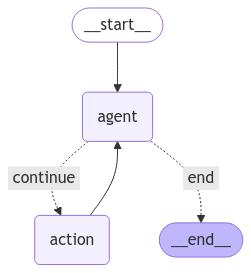

In [48]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
# memory = SqliteSaver.from_conn_string(":memory:")
# app = workflow.compile(checkpointer=memory, interrupt_before=["action"])

In [56]:
from langgraph.checkpoint.sqlite import SqliteSaver

ImportError: cannot import name 'get_checkpoint_metadata' from 'langgraph.checkpoint.base' (C:\Users\Dell\.conda\envs\autogen\Lib\site-packages\langgraph\checkpoint\base\__init__.py)

In [55]:
graph.invoke({"Hi"})

InvalidUpdateError: Expected dict, got {'Hi'}
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_GRAPH_NODE_RETURN_VALUE